### Import required libraries for data handling, visualization, preprocessing, model building, and evaluation.

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report, precision_score, recall_score, confusion_matrix,roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

### Load the e-commerce customer dataset

In [24]:
df = pd.read_csv(r"C:\Users\MADHIVANAN\Downloads\ecommerce_customers_intermediate.csv")
df.head(10)

,user_id,age,gender,country,city,device_type,traffic_source,sessions,time_spent_min,pages_visited,add_to_cart,purchase,order_value,discount_applied,customer_type
0,1,31.0,Male,USA,New York,Mobile,Organic,3,38.65,7,1,0,20.62,0,New
1,2,45.0,Male,Australia,Melbourne,Desktop,Organic,2,6.84,18,1,1,55.86,1,New
2,3,22.0,Female,Germany,Munich,Tablet,Organic,4,10.64,10,0,0,79.15,1,New
3,4,21.0,Female,USA,San Francisco,Mobile,Paid,3,17.25,21,0,0,141.62,0,New
4,5,42.0,Male,India,Chennai,Tablet,Paid,5,8.99,9,0,0,75.95,0,New
5,6,44.0,Female,India,Bangalore,Mobile,Organic,5,6.91,22,0,0,124.07,0,Returning
6,7,21.0,Female,India,Delhi,Desktop,Social,2,1.56,5,0,0,63.75,1,Returning
7,8,46.0,Male,Canada,Toronto,Mobile,Social,6,14.21,16,0,1,224.74,1,New
8,9,58.0,Male,UK,Manchester,Mobile,Social,5,19.52,13,1,1,25.79,1,New
9,10,44.0,Female,Germany,Berlin,Tablet,Referral,9,16.52,12,0,1,209.55,0,New


Features = user_id, age, gender, country, city, device_type, traffic_source, sessions, time_spent_min, pages_visited, add_to_cart, order_value, discount_applied, customer_type

Target = purchase

### Exploratory Data Analysis (EDA) 

Checks such as shape, columns

In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           50000 non-null  int64  
 1   age               48000 non-null  float64
 2   gender            50000 non-null  object 
 3   country           50000 non-null  object 
 4   city              50000 non-null  object 
 5   device_type       50000 non-null  object 
 6   traffic_source    50000 non-null  object 
 7   sessions          50000 non-null  int64  
 8   time_spent_min    50000 non-null  float64
 9   pages_visited     50000 non-null  int64  
 10  add_to_cart       50000 non-null  int64  
 11  purchase          50000 non-null  int64  
 12  order_value       47000 non-null  float64
 13  discount_applied  50000 non-null  int64  
 14  customer_type     50000 non-null  object 
dtypes: float64(3), int64(6), object(6)
memory usage: 5.7+ MB
None


Checks basic statistics

In [26]:
df.describe()

,user_id,age,sessions,time_spent_min,pages_visited,add_to_cart,purchase,order_value,discount_applied
count,50000.000000,48000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,47000.000000,50000.000000
mean,25000.500000,38.417250,3.990920,11.993590,12.504720,0.349780,0.278720,150.543979,0.301900
std,14433.901067,12.110414,1.729398,11.967093,6.924078,0.476905,0.448374,152.372554,0.459087
min,1.000000,18.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,28.000000,3.000000,3.460000,6.000000,0.000000,0.000000,43.220000,0.000000
50%,25000.500000,38.000000,4.000000,8.350000,13.000000,0.000000,0.000000,103.050000,0.000000
75%,37500.250000,49.000000,5.000000,16.592500,19.000000,1.000000,1.000000,207.742500,1.000000
max,50000.000000,59.000000,14.000000,129.040000,24.000000,1.000000,1.000000,1686.700000,1.000000


Checks Missing values to understand data quality

In [27]:
print(f"{df.isna().sum()} \n=======================================\n{df.isna().sum()/len(df)*100}")

user_id                0
age                 2000
gender                 0
country                0
city                   0
device_type            0
traffic_source         0
sessions               0
time_spent_min         0
pages_visited          0
add_to_cart            0
purchase               0
order_value         3000
discount_applied       0
customer_type          0
dtype: int64 
user_id             0.0
age                 4.0
gender              0.0
country             0.0
city                0.0
device_type         0.0
traffic_source      0.0
sessions            0.0
time_spent_min      0.0
pages_visited       0.0
add_to_cart         0.0
purchase            0.0
order_value         6.0
discount_applied    0.0
customer_type       0.0
dtype: float64


Checks Duplicated Values

In [28]:
df.duplicated().sum()

np.int64(0)

Box plots are used to visualize the distribution and detect outliers across numerical features in the dataset

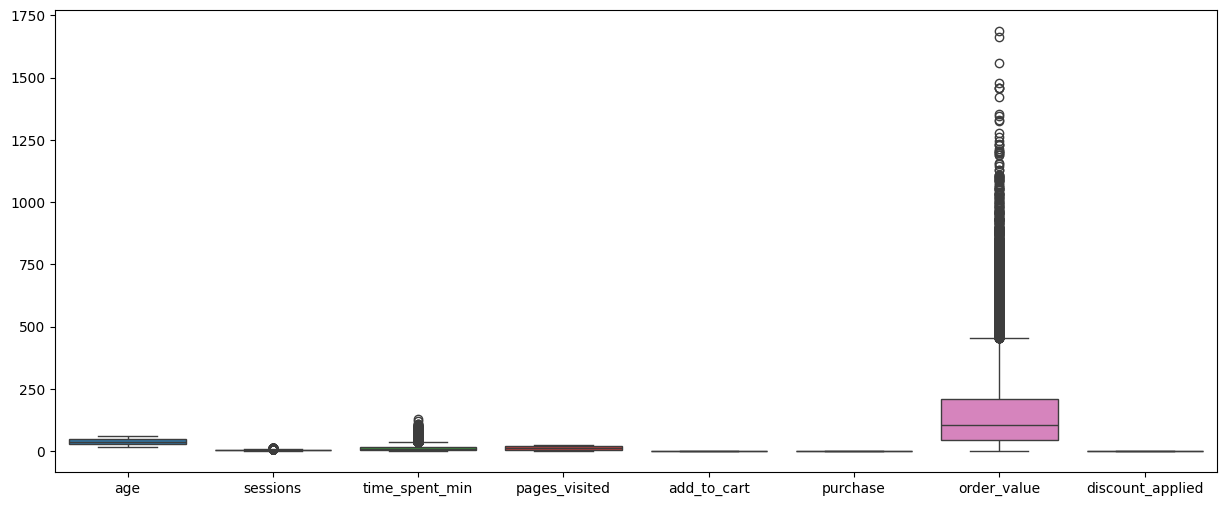

In [29]:
plt.figure(figsize=(15,6))
sns.boxplot(data= df.drop(columns='user_id'))
plt.show()

Missing values in numerical features are handled using mean imputation for age and median imputation for order value to reduce the impact of outliers.

In [30]:
df['age'] = df['age'].fillna(df['age'].mean())
df['order_value'] = df['order_value'].fillna(df['order_value'].median())

## visualization

### Univariate Analysis

The distribution of the target variable (purchase) is visualized to identify class imbalance between purchase and non-purchase outcomes

purchase
0    36064
1    13936
Name: count, dtype: int64


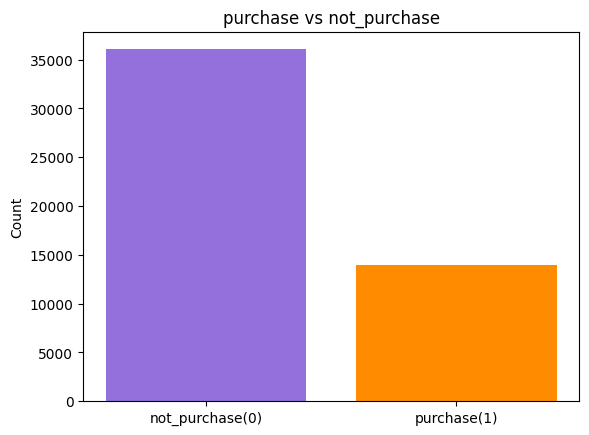

In [31]:
print(df['purchase'].value_counts()) # imbalanced
label = ['not_purchase(0)', 'purchase(1)']
purchase_count = [36064, 13936]
plt.bar(label, purchase_count, color= ["mediumpurple", "darkorange"])
plt.ylabel("Count")
plt.title("purchase vs not_purchase")
plt.show()

### Univariate Analysis 

Order values are binned into meaningful ranges to visualize the distribution of customer spending using a count plot

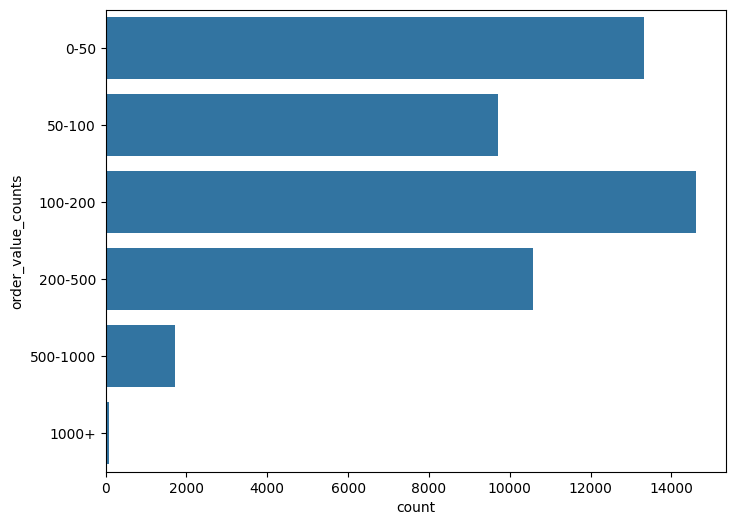

In [32]:
bins = [0, 50, 100, 200, 500, 1000, 1700]
labels = ['0-50','50-100','100-200','200-500','500-1000','1000+']
df['order_value_counts'] = pd.cut(df['order_value'],labels=labels, bins=bins)
df['order_value_counts'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.countplot(data=df['order_value_counts'])
plt.show()

### Univariate Analysis 

Customer ages are grouped into defined age ranges to analyze and visualize the age distribution using a bar chart

age_group
30-40    13651
20-30    11484
40-50    11259
50-60    10178
18-20     2254
Name: count, dtype: int64


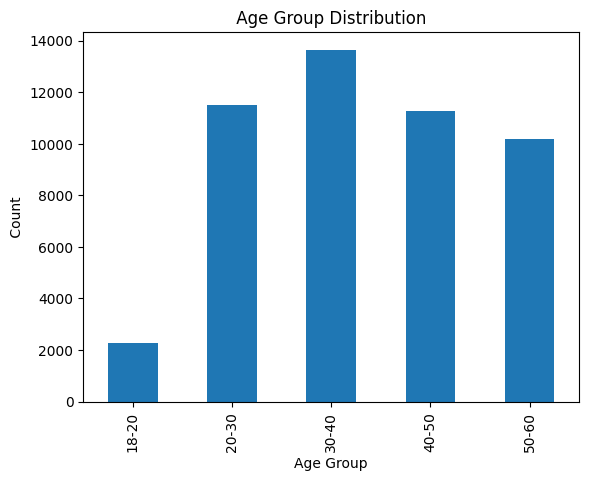

In [33]:
bins = [18,20,30,40,50,60]
labels = ['18-20','20-30','30-40','40-50','50-60'] 
df['age_group'] = pd.cut(df['age'], labels=labels, bins = bins)
age_count= df['age_group'].value_counts()
print(age_count)
df['age_group'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Age Group")
plt.ylabel(" Count ")
plt.title(" Age Group Distribution ")
plt.show()

### Bivariate Analysis

Gender-wise distribution is analyzed against purchase behavior to understand how purchasing differs across genders

gender
Female    25123
Male      24877
Name: count, dtype: int64


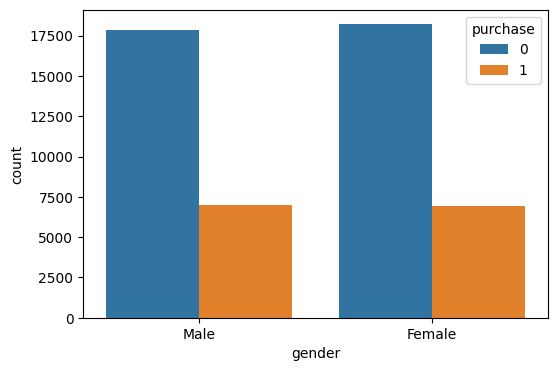

In [34]:
gender_df = df['gender'].value_counts()
print(gender_df)
plt.figure(figsize=(6,4))
sns.countplot(x= 'gender', hue= 'purchase', data= df)
plt.show()

### Bivariate Analysis 

Country-wise customer distribution is analyzed against purchase behavior to compare purchasing patterns across different countries

country
India        17608
USA          12441
UK            5106
Australia     4977
Canada        4949
Germany       4919
Name: count, dtype: int64


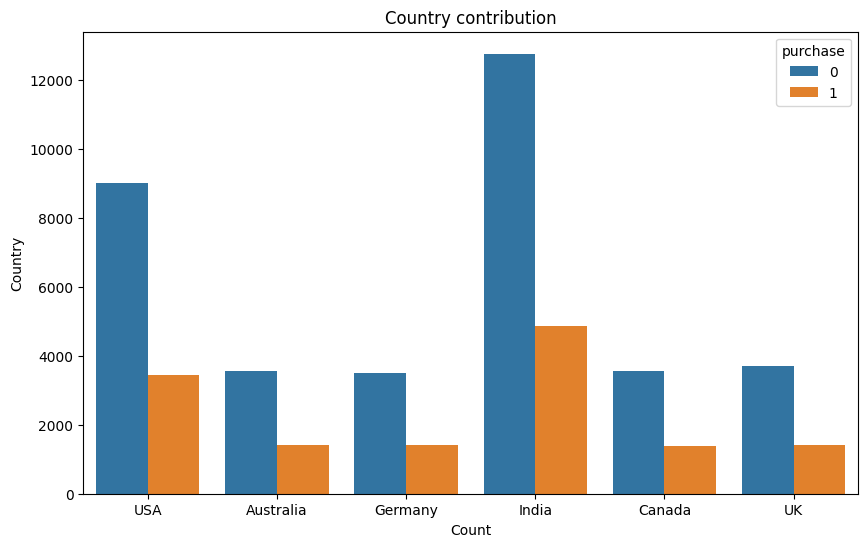

In [35]:
country_count = df['country'].value_counts()
print(country_count)
plt.figure(figsize=(10,6))
sns.countplot(x='country', hue='purchase',data=df)
plt.xlabel("Count")
plt.ylabel("Country")
plt.title("Country contribution")
plt.show()

### Univariate Analysis (per country)

City-wise customer frequency is computed separately for each country to understand geographic distribution within countries

In [36]:
Country = ['India', 'USA', 'UK', 'Australia', 'Canada', 'Germany']
for i in Country:
    df_country = df[df['country'] == i]
    df_city_count = df_country['city'].value_counts()
    print(f"============={i}============= \n{df_city_count}")
    # plt.figure(figsize=(8,6))
    # sns.countplot(data=df_city_count)
    # plt.show() 

=============India============= 
city
Bangalore    4475
Mumbai       4415
Chennai      4403
Delhi        4315
Name: count, dtype: int64
=============USA============= 
city
San Francisco    4191
New York         4126
Chicago          4124
Name: count, dtype: int64
=============UK============= 
city
Manchester    2558
London        2548
Name: count, dtype: int64
=============Australia============= 
city
Melbourne    2506
Sydney       2471
Name: count, dtype: int64
=============Canada============= 
city
Vancouver    2481
Toronto      2468
Name: count, dtype: int64
=============Germany============= 
city
Berlin    2565
Munich    2354
Name: count, dtype: int64


### Feature Engineering 

In [37]:
df['pages_per_session'] = df['pages_visited'] / (df['sessions'] + 1)
df['time_per_session'] = df['time_spent_min'] / (df['sessions'] + 1)
df['time_per_page'] = df['time_spent_min'] / (df['pages_visited'] + 1)
df.loc[(df['add_to_cart'] == 0) & (df['discount_applied']==0),'order_value'] = 0
df = df.drop(columns=['user_id', 'pages_visited', 'time_spent_min','sessions'])

A correlation heatmap is used to examine the strength and direction of relationships among numerical features

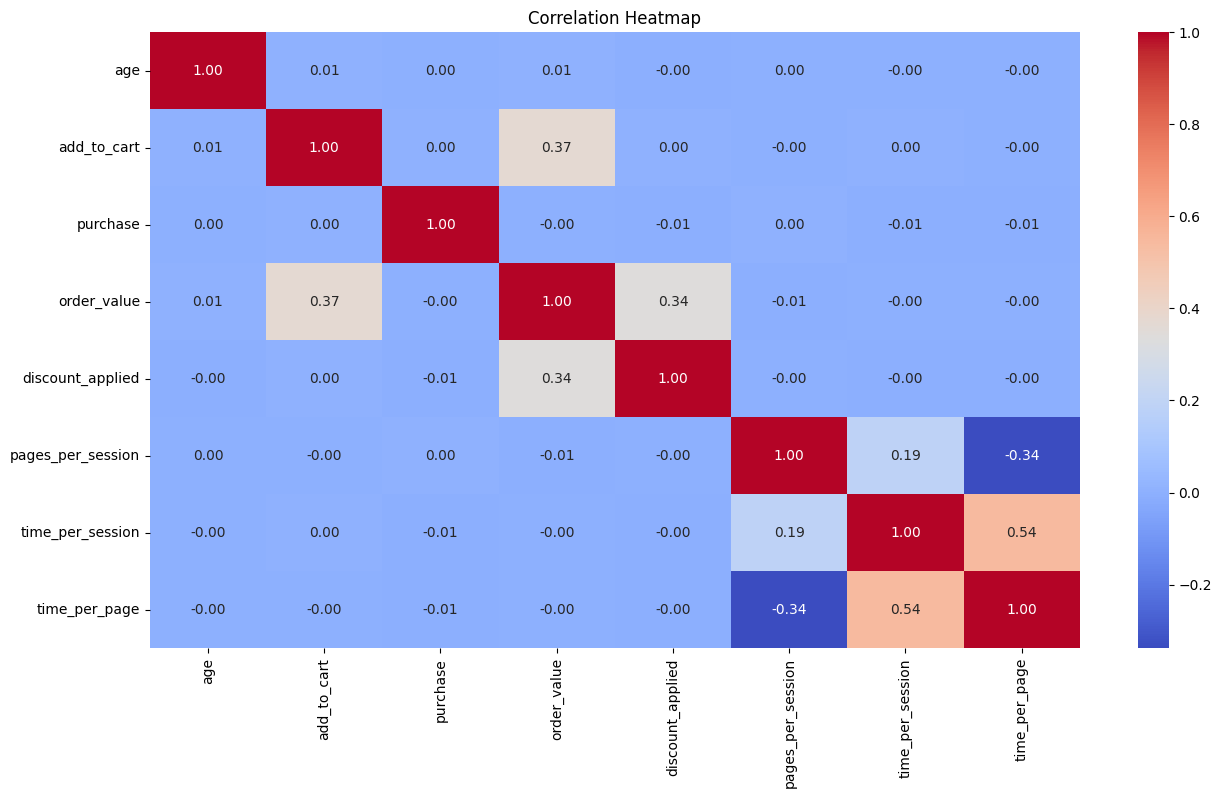

In [38]:
plt.figure(figsize=(15,8))
sns.heatmap(data=df.corr(numeric_only= True), annot=True, cmap= 'coolwarm', fmt= '.2f')
plt.title("Correlation Heatmap")
plt.show()

In [39]:
df.shape

(50000, 16)

Feature Selection : Selects the most relevant features for model training

In [40]:
x = df.drop(columns=['purchase', 'device_type', 'order_value_counts', 'age_group'])
y= df['purchase']

In [41]:
x.shape

(50000, 12)

### Encoding categorical features

In [42]:
x_encoder = pd.get_dummies(x,columns=['gender', 'country', 'city', 'traffic_source', 'customer_type'], drop_first= True)

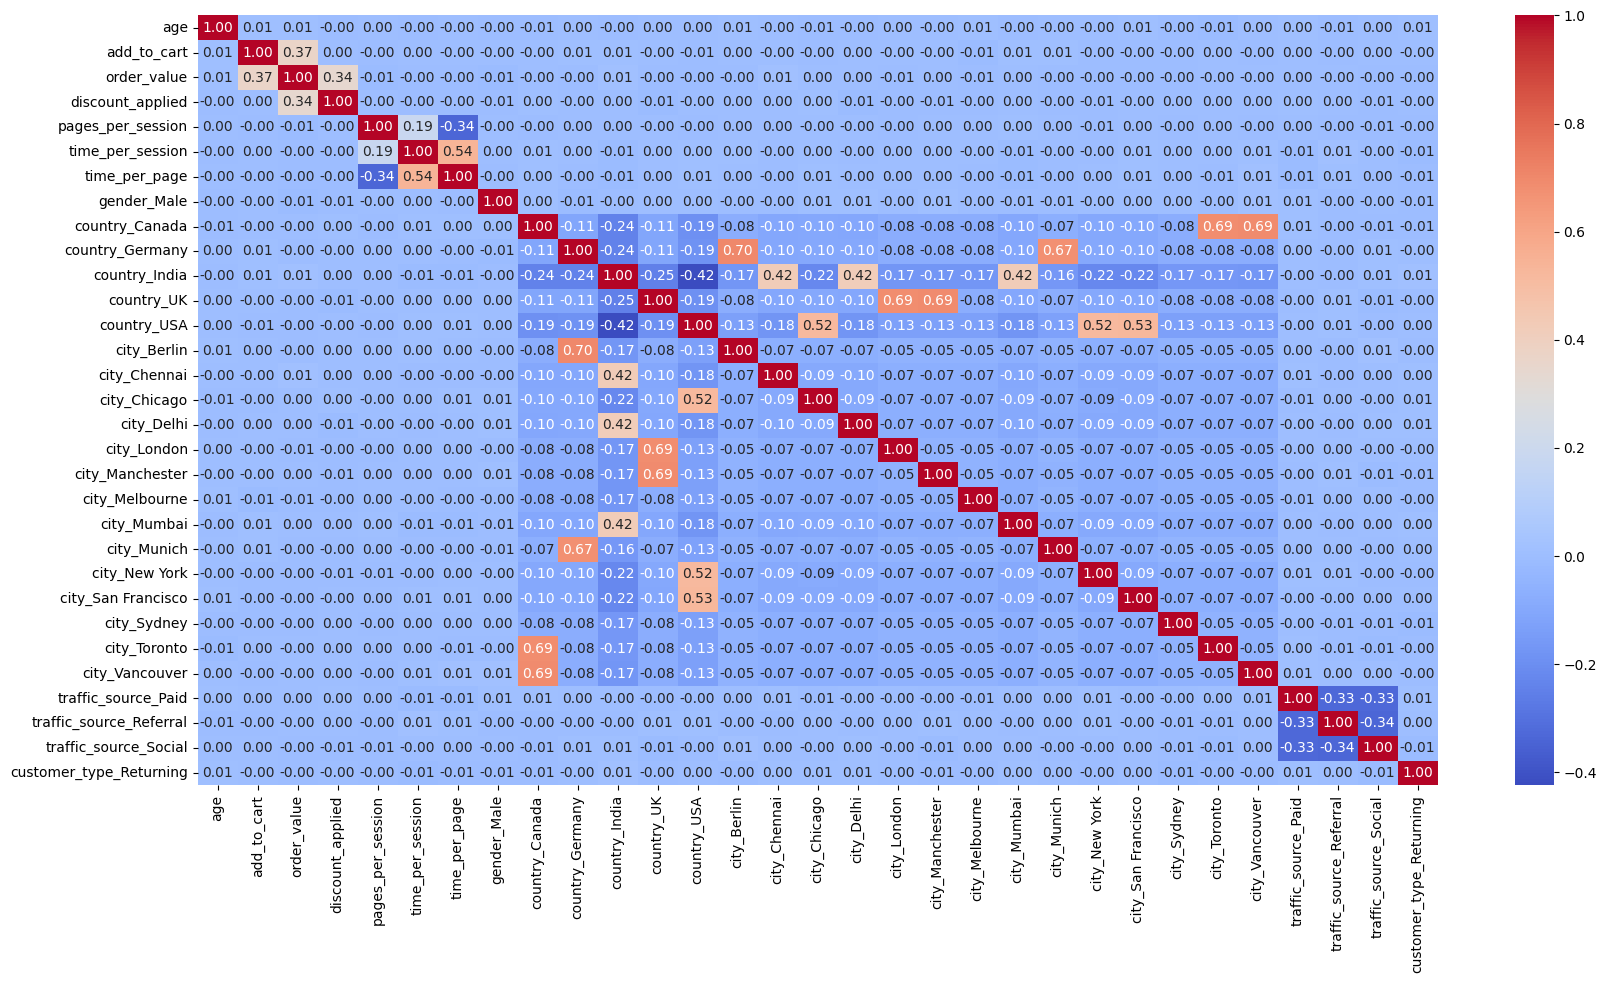

In [43]:
plt.figure(figsize=(20,10))
sns.heatmap(data= x_encoder.corr(numeric_only=True), annot=True, cmap= 'coolwarm', fmt='.2f')
plt.show()

### Data Preprocessing for Modeling 

Splits dataset into training & testing sets : Train-Test Split

In [44]:
x_train,x_test,y_train,y_test = train_test_split(x_encoder,y,test_size=0.2,random_state=42)

Class Imbalance Handling: SMOTE is applied to the training data to synthetically oversample the minority class and balance the target distribution

In [45]:
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

Scaling numeric features - standardizes features

In [46]:
scaler = StandardScaler()
X_train =scaler.fit_transform(x_train_res)
X_test =scaler.transform(x_test)

### Model Selection & Training

Model Initialization and Selection

In [47]:
models = [LogisticRegression(), RandomForestClassifier(), GradientBoostingClassifier(), KNeighborsClassifier(), SVC()]

Stratified K-Fold cross-validation is used to evaluate multiple models using ROC-AUC, ensuring class proportions are preserved across folds

In [48]:
skf = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)
for Model in models:
    cv_score = cross_val_score(Model, X_train, y_train_res, scoring='roc_auc',cv= skf, n_jobs= -1 )
    print(f'-----------------------------------{Model}-----------------------------------')
    print(f'Cross Validation Score (k= {skf}: {cv_score})')
    print(f'Standard Deviation : {cv_score.std():.2f}')
    print(f'CV ROC-AUC: {cv_score.mean()}')

-----------------------------------LogisticRegression()-----------------------------------
Cross Validation Score (k= StratifiedKFold(n_splits=5, random_state=42, shuffle=True): [0.76921248 0.77484281 0.78090588 0.7652977  0.77479011])
Standard Deviation : 0.01
CV ROC-AUC: 0.7730097950714784
-----------------------------------RandomForestClassifier()-----------------------------------
Cross Validation Score (k= StratifiedKFold(n_splits=5, random_state=42, shuffle=True): [0.80976812 0.82123584 0.82139755 0.8129649  0.81933046])
Standard Deviation : 0.00
CV ROC-AUC: 0.8169393721785914
-----------------------------------GradientBoostingClassifier()-----------------------------------
Cross Validation Score (k= StratifiedKFold(n_splits=5, random_state=42, shuffle=True): [0.77103142 0.77563945 0.78372672 0.77047029 0.77901849])
Standard Deviation : 0.00
CV ROC-AUC: 0.7759772734768605
-----------------------------------KNeighborsClassifier()-----------------------------------
Cross Validation

### Hyperparameter Tuning (Random Forest Classifier) 

In [49]:
RFC = RandomForestClassifier(random_state=42)
RFC_SKF = StratifiedKFold(n_splits= 5 , shuffle= True, random_state= 42)

Uses RandomizedSearchCV to find the best hyperparameters for Random Forest Classifier

In [50]:
param_grid = {'n_estimators': [300, 500],'max_depth': [None, 10, 20],'min_samples_split': [2, 5],'min_samples_leaf': [1, 2],'max_features': ['sqrt'],'class_weight': ['balanced']}

In [ ]:
randomsearchcv = RandomizedSearchCV(estimator=RFC,param_distributions=param_grid,scoring='roc_auc',cv=RFC_SKF,n_jobs=-1,verbose=2)
randomsearchcv.fit(X_train, y_train_res)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'class_weight': ['balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], ...}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


### Model Evaluation on Test Data : Evaluates the tuned Gradient Boosting model

In [52]:
print(f"Best Parameter: {randomsearchcv.best_params_}")
print(f"ROC AUC Score : {randomsearchcv.best_score_}")

Best Parameter: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
ROC AUC Score : 0.820384613803496


In [53]:
RFC_best_model = randomsearchcv.best_estimator_

In [54]:
y_pred = RFC_best_model.predict(X_test)
y_pred_proba = RFC_best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Assessed based on Recall, Precision, F1-score, and ROC-AUC for the best-performing models")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc:.4f}")

Assessed based on Recall, Precision, F1-score, and ROC-AUC for the best-performing models

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.87      0.79      7261
           1       0.28      0.13      0.18      2739

    accuracy                           0.67     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.60      0.67      0.63     10000

ROC-AUC Score: 0.5031
